In [2]:
import tensorflow as tf
        
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

I0000 00:00:1787943070.847456     569 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787943071.718179     569 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787943073.877934     569 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [23]:
# ==========================================
# 1. GPU VRAM Safety Protocol
# ==========================================
# Forces TensorFlow to only use the VRAM it needs, preventing OOM crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

GPU Memory Growth Enabled


In [42]:
# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
CSV_FILE = r"../Dataset/CleanedDataSetNew.csv"                  # Your dataset CSV
IMAGE_DIR = r"../Dataset/AllImages"          # Folder containing the ESP32-CAM images
TARGET_COLUMN = "irradiance"           # The CSV column with your W/m^2 values
IMAGE_FILENAME_COLUMN = "dateTime"     # The CSV column with your image names

IMG_SIZE = 380                         # Required for EfficientNetB4
BATCH_SIZE = 6                        # Keep low (8 or 16) if running on laptop CPU/GPU
EPOCHS = 30                            # Maximum training iterations
LEARNING_RATE = 0.001


In [25]:
# ==========================================
# 2. DATASET PREPARATION (Pandas) - UPDATED
# ==========================================
def prepare_dataframe():
    print("📊 Loading CSV dataset...")
    df = pd.read_csv(CSV_FILE)
    
    # 🚨 FIX 1: Force Pandas to treat the filename/dateTime column as strings
    df[IMAGE_FILENAME_COLUMN] = df[IMAGE_FILENAME_COLUMN].astype(str)
    
    # Get list of physical image files
    image_list = [filename[:12] for filename in os.listdir(IMAGE_DIR)]
    
    # Filter dataset to only include rows where the image actually exists
    df["ImageBool"] = df[IMAGE_FILENAME_COLUMN].isin(image_list)
    df = df[df["ImageBool"] == True]
    
    # Construct the full file paths
    df["file_path"] = df[IMAGE_FILENAME_COLUMN].apply(
        lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg") # Adjust to .png if needed
    )
    
    # 🚨 FIX 2: Explicitly cast arrays to string and float32
    file_paths = df["file_path"].astype(str).values
    targets = df[TARGET_COLUMN].astype("float32").values
    
    print(f"✅ Found {len(df)} valid image-irradiance pairs.")
    return file_paths, targets

In [26]:



# ==========================================
# 3. TENSORFLOW DATA PIPELINE - UPDATED
# ==========================================
def process_path(file_path, irradiance):
    # Read the physical file
    img = tf.io.read_file(file_path)
    # Decode JPEG to a tensor
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize to EfficientNetB4 specs (380x380)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    
    return img, irradiance

def create_tf_dataset(file_paths, targets):
    # 🚨 FIX 3: Cast dataset inputs to tf.string and tf.float32 explicitly
    dataset = tf.data.Dataset.from_tensor_slices((
        tf.cast(file_paths, tf.string),
        tf.cast(targets, tf.float32)
    ))
    
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

In [27]:
# ==========================================
# 4. MODEL ARCHITECTURE
# ==========================================
def build_irradiance_model():
    print("⚙️ Building EfficientNetB4 Regression Architecture...")
    
    base_model = EfficientNetB4(
        weights='imagenet', 
        include_top=False, 
        input_shape=(IMG_SIZE, IMG_SIZE, 3) 
    )
    
    # Freeze the base model to train only the custom regression head first
    base_model.trainable = False 

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3), 
        
        # Single output neuron with ReLU (Irradiance cannot be negative)
        layers.Dense(1, activation='relu', name='irradiance_output') 
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.Huber(),
        metrics=['mae'] 
    )
    
    return model

In [12]:
paths, targets = prepare_dataframe()

📊 Loading CSV dataset...
✅ Found 44048 valid image-irradiance pairs.


In [28]:
BASE_DIR = os.path.dirname(os.getcwd())

INPUT_PATH = os.path.join(BASE_DIR, "Dataset/Download Images")
OUTPUT_PATH = os.path.join(BASE_DIR, "Dataset/AllImages")
CSV_FILE = os.path.join(BASE_DIR, "Dataset/DataSet.csv")
def check():
    files = os.listdir(OUTPUT_PATH)
    #print(files)
    Type = set()  
    z = []
    for i in files:
        Type.add(i[12:])
        if i[12:] == ".zip":
            z.append(i)

    print(Type)

check()

{'.jpg'}


In [15]:
# ==========================================
# 5. EXECUTION & TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    # 1. Prepare data
    paths, targets = prepare_dataframe()
    
    # Optional: Split into training and validation sets (80/20 split)
    split_index = int(len(paths) * 0.8)
    train_paths, val_paths = paths[:split_index], paths[split_index:]
    train_targets, val_targets = targets[:split_index], targets[split_index:]
    
    # 2. Build TensorFlow Datasets
    print("🚀 Building TensorFlow Data Pipelines...")
    train_dataset = create_tf_dataset(train_paths, train_targets)
    val_dataset = create_tf_dataset(val_paths, val_targets)
    
    # 3. Build Model
    model = build_irradiance_model()
    model.summary()
    
    # 4. Set up Callbacks
    # Saves the best version of the model automatically
    checkpoint = ModelCheckpoint(
        "efficientnet_b4_solar.keras", 
        monitor="val_loss", 
        save_best_only=True, 
        verbose=1
    )
    # Stops training early if the model stops improving, saving time
    early_stop = EarlyStopping(
        monitor="val_loss", 
        patience=5, 
        restore_best_weights=True
    )
    
    # 5. Train the Model
    print("🔥 Starting Training...")
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[checkpoint, early_stop]
    )
    
    print("🎉 Training Complete! Model saved as 'efficientnet_b4_solar.keras'")

📊 Loading CSV dataset...
✅ Found 44048 valid image-irradiance pairs.
🚀 Building TensorFlow Data Pipelines...
⚙️ Building EfficientNetB4 Regression Architecture...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ irradiance_output (Dense)       │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,133,088 (69.17 MB)

 Trainable params: 459,265 (1.75 MB)

 Non-trainable params: 17,673,823 (67.42 MB)

🔥 Starting Training...
Epoch 1/30


/home/chinmay/tf-gpu/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786721063.075058     689 shuffle_dataset_op.cc:453] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 672 of 1000
I0000 00:00:1786721068.065168     689 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1786721068.730529     631 service.cc:153] XLA service 0x7eb59c0b14f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786721068.731221     631 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786721073.550851     631 dump_mlir_util.cc:26

5873/5873 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 98.2632 - mae: 98.7585
Epoch 1: val_loss improved from None to 97.59549, saving model to efficientnet_b4_solar.keras

Epoch 1: finished saving model to efficientnet_b4_solar.keras
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 613s 91ms/step - loss: 98.2632 - mae: 98.7585 - val_loss: 97.5955 - val_mae: 98.0938
Epoch 2/30
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 74.3486 - mae: 74.8420
Epoch 2: val_loss improved from 97.59549 to 75.92367, saving model to efficientnet_b4_solar.keras

Epoch 2: finished saving model to efficientnet_b4_solar.keras
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 484s 81ms/step - loss: 74.3486 - mae: 74.8420 - val_loss: 75.9237 - val_mae: 76.4220
Epoch 3/30
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 69.7780 - mae: 70.2711
Epoch 3: val_loss improved from 75.92367 to 68.07067, saving model to efficientnet_b4_solar.keras

Epoch 3: finished saving model to efficientnet_b4_solar.keras
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 471s 80ms/s

In [20]:
bad_images = []

for i, path in enumerate(paths):
    try:
        img = tf.io.read_file(path)
        tf.io.decode_jpeg(img, channels=3)
    except Exception as e:
        bad_images.append((path, str(e)))

print("BAD IMAGES:", len(bad_images))

for x in bad_images[:20]:
    print(x)

I0000 00:00:1786687892.902142    2021 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1768 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
E0000 00:00:1786687978.031271    2021 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 1518/1536
W0000 00:00:1786687978.031785    2021 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop window.
E0000 00:00:1786687988.468619    2021 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 1422/1536
W0000 00:00:1786687988.468663    2021 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop window.
E0000 00:00:1786688000.692755    2021 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 1150/1536
E0000 00:00:1786688001.427280    2021 jpeg_mem.cc:331] Prematur

BAD IMAGES: 19
('../Dataset/AllImages/202405230540.jpg', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} jpeg::Uncompress failed. Invalid JPEG data or crop window. [Op:DecodeJpeg]')
('../Dataset/AllImages/202406080600.jpg', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} jpeg::Uncompress failed. Invalid JPEG data or crop window. [Op:DecodeJpeg]')
('../Dataset/AllImages/202406271200.jpg', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} jpeg::Uncompress failed. Invalid JPEG data or crop window. [Op:DecodeJpeg]')
('../Dataset/AllImages/202406281240.jpg', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} jpeg::Uncompress failed. Invalid JPEG data or crop window. [Op:DecodeJpeg]')
('../Dataset/AllImages/202406301010.jpg', '{{function_node __wrapped__DecodeJpeg_device_/job:localhost/replica:0/task:0/device:CPU:0}} jp

In [22]:
for path, error in bad_images:
    if os.path.exists(path):
        os.remove(path)
        print("Deleted:", path)

print(f"\nDeleted {len(bad_images)} corrupted images.")

Deleted: ../Dataset/AllImages/202405230540.jpg
Deleted: ../Dataset/AllImages/202406080600.jpg
Deleted: ../Dataset/AllImages/202406271200.jpg
Deleted: ../Dataset/AllImages/202406281240.jpg
Deleted: ../Dataset/AllImages/202406301010.jpg
Deleted: ../Dataset/AllImages/202407011340.jpg
Deleted: ../Dataset/AllImages/202407100950.jpg
Deleted: ../Dataset/AllImages/202407300920.jpg
Deleted: ../Dataset/AllImages/202407301300.jpg
Deleted: ../Dataset/AllImages/202408160450.jpg
Deleted: ../Dataset/AllImages/202408160540.jpg
Deleted: ../Dataset/AllImages/202408290620.jpg
Deleted: ../Dataset/AllImages/202409051240.jpg
Deleted: ../Dataset/AllImages/202409071500.jpg
Deleted: ../Dataset/AllImages/202409081650.jpg
Deleted: ../Dataset/AllImages/202409101040.jpg
Deleted: ../Dataset/AllImages/202410031800.jpg
Deleted: ../Dataset/AllImages/202410041250.jpg
Deleted: ../Dataset/AllImages/202410110620.jpg

Deleted 19 corrupted images.


In [18]:
#pip install matplotlib

In [35]:
import tensorflow as tf
import time
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# ==========================================
# BENCHMARK MODEL BUILDER
# ==========================================

IMG_SIZE_BENCHMARK = (224, 224)
INPUT_SHAPE = IMG_SIZE_BENCHMARK + (3,)


def build_benchmark_model(model_name):
    """Builds and compiles a specific architecture."""

    inputs = tf.keras.Input(shape=INPUT_SHAPE)

    if model_name == "Custom_CNN":

        x = tf.keras.layers.Rescaling(1./255)(inputs)
        x = tf.keras.layers.Conv2D(
            32, (3, 3), activation='relu'
        )(x)
        x = tf.keras.layers.MaxPooling2D(2, 2)(x)

        x = tf.keras.layers.Conv2D(
            64, (3, 3), activation='relu'
        )(x)
        x = tf.keras.layers.MaxPooling2D(2, 2)(x)

        x = tf.keras.layers.GlobalAveragePooling2D()(x)

    elif model_name == "MobileNetV2":

        x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

        base_model = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights='imagenet',
            input_shape=INPUT_SHAPE
        )

        base_model.trainable = False
        x = base_model(x)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)

    elif model_name == "ResNet50":

        x = tf.keras.applications.resnet50.preprocess_input(inputs)

        base_model = tf.keras.applications.ResNet50(
            include_top=False,
            weights='imagenet',
            input_shape=INPUT_SHAPE
        )

        base_model.trainable = False
        x = base_model(x)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)

    elif model_name == "EfficientNetB0":

        x = inputs

        base_model = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights='imagenet',
            input_shape=INPUT_SHAPE
        )

        base_model.trainable = False
        x = base_model(x)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Universal Regression Head
    x = tf.keras.layers.Dense(
        256, activation='relu'
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation='linear',
        name="irradiance_output"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name=model_name
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss='mse',
        metrics=['mae']
    )

    return model

In [44]:
# ==========================================
# RECREATE DATA SPLIT
# ==========================================

paths, targets = prepare_dataframe()

split_index = int(len(paths) * 0.8)

train_paths = paths[:split_index]
val_paths = paths[split_index:]

train_targets = targets[:split_index]
val_targets = targets[split_index:]

print("Total samples:", len(paths))
print("Training samples:", len(train_paths))
print("Validation samples:", len(val_paths))

📊 Loading CSV dataset...
✅ Found 44048 valid image-irradiance pairs.
Total samples: 44048
Training samples: 35238
Validation samples: 8810


In [46]:
# ==========================================
# CREATE 224x224 BENCHMARK DATASETS
# ==========================================

def process_benchmark_path(file_path, irradiance):

    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])

    return img, irradiance


def create_benchmark_dataset(file_paths, targets, shuffle=True):

    dataset = tf.data.Dataset.from_tensor_slices((
        tf.cast(file_paths, tf.string),
        tf.cast(targets, tf.float32)
    ))

    dataset = dataset.map(
        process_benchmark_path,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


benchmark_train_dataset = create_benchmark_dataset(
    train_paths,
    train_targets,
    shuffle=True
)

benchmark_val_dataset = create_benchmark_dataset(
    val_paths,
    val_targets,
    shuffle=False
)

print("✅ 224x224 benchmark datasets ready!")

✅ 224x224 benchmark datasets ready!


In [47]:
# ==========================================
# RUN BENCHMARK LOOP
# ==========================================

models_to_test = ["Custom_CNN","MobileNetV2","ResNet50","EfficientNetB0"]

results = []

EPOCHS = 5

print("🚀 Starting Model Benchmark...")

for name in models_to_test:

    print(f"\n--- Training {name} ---")

    model = build_benchmark_model(name)

    start_time = time.time()

    history = model.fit(
        benchmark_train_dataset,
        validation_data=benchmark_val_dataset,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    best_val_mae = min(
        history.history['val_mae']
    )

    results.append({
        "Model": name,
        "Best Val MAE (W/m²)": round(best_val_mae, 2),
        "Training Time (s)": round(training_time, 2),
        "Parameters": model.count_params()
    })

print("\n✅ Benchmark training complete!")

🚀 Starting Model Benchmark...

--- Training Custom_CNN ---
Epoch 1/5


/home/chinmay/tf-gpu/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787945424.683267    1057 service.cc:153] XLA service 0x7dd894033b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787945424.687797    1057 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787945425.488111    1057 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787945426.646353    1057 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787945426.832932    1057 dot_merger.cc:481] Mergi

5873/5873 ━━━━━━━━━━━━━━━━━━━━ 148s 21ms/step - loss: 78768.2422 - mae: 232.3535 - val_loss: 70588.1172 - val_mae: 215.5523
Epoch 2/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 106s 18ms/step - loss: 48686.6211 - mae: 170.5999 - val_loss: 45069.7734 - val_mae: 168.9749
Epoch 3/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 144s 24ms/step - loss: 28901.3145 - mae: 125.7098 - val_loss: 34943.2969 - val_mae: 144.8536
Epoch 4/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 133s 22ms/step - loss: 21889.7695 - mae: 105.6470 - val_loss: 25644.8613 - val_mae: 120.2059
Epoch 5/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 120s 20ms/step - loss: 19452.2129 - mae: 98.2037 - val_loss: 21008.6875 - val_mae: 105.5528

--- Training MobileNetV2 ---
Epoch 1/5


I0000 00:00:1787946099.486745    1057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_162658__.115


5873/5873 ━━━━━━━━━━━━━━━━━━━━ 172s 25ms/step - loss: 19337.0840 - mae: 101.8053 - val_loss: 29163.9473 - val_mae: 135.9306
Epoch 2/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 133s 22ms/step - loss: 12776.7803 - mae: 79.9848 - val_loss: 21746.0684 - val_mae: 113.3101
Epoch 3/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 156s 26ms/step - loss: 11548.8213 - mae: 75.3968 - val_loss: 17543.7031 - val_mae: 100.1156
Epoch 4/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 140s 23ms/step - loss: 10980.0918 - mae: 73.3778 - val_loss: 15781.9619 - val_mae: 93.6557
Epoch 5/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 126s 21ms/step - loss: 10521.9697 - mae: 71.6856 - val_loss: 16323.8896 - val_mae: 96.3569

--- Training ResNet50 ---
Epoch 1/5


I0000 00:00:1787946843.696545    1060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_322868__.178
W0000 00:00:1787946854.953481    1060 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.09GiB (rounded to 1167589888)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1787946855.001941    1060 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1787946855.001967    1060 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 236, Chunks in use: 231. 59.0KiB allocated for chunks. 57.8KiB in use in bin. 18.0KiB client-requested in use in bin.
I0000 00:00:1787946855.001990    1060 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 112, Chunks in use: 110. 68.8KiB allocated for chunks. 67.5KiB in use in bin. 60.8KiB client-requested in use in b

5873/5873 ━━━━━━━━━━━━━━━━━━━━ 263s 38ms/step - loss: 13456.1768 - mae: 83.6321 - val_loss: 12285.6895 - val_mae: 84.4529
Epoch 2/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 210s 35ms/step - loss: 8599.1855 - mae: 64.6348 - val_loss: 9253.6592 - val_mae: 69.2931
Epoch 3/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 210s 35ms/step - loss: 7910.1724 - mae: 61.1995 - val_loss: 14007.0664 - val_mae: 90.9753
Epoch 4/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 212s 36ms/step - loss: 7611.9487 - mae: 60.1218 - val_loss: 11639.1543 - val_mae: 80.4579
Epoch 5/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 212s 36ms/step - loss: 7332.2715 - mae: 58.5982 - val_loss: 10973.4443 - val_mae: 78.5287

--- Training EfficientNetB0 ---
Epoch 1/5


I0000 00:00:1787947959.288393    1055 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_489045__.247


5873/5873 ━━━━━━━━━━━━━━━━━━━━ 198s 26ms/step - loss: 20164.4277 - mae: 105.9610 - val_loss: 16503.7402 - val_mae: 96.2859
Epoch 2/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 134s 22ms/step - loss: 11778.1123 - mae: 78.1759 - val_loss: 12896.6270 - val_mae: 81.7838
Epoch 3/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 133s 22ms/step - loss: 10469.1543 - mae: 72.6125 - val_loss: 13625.7129 - val_mae: 83.4793
Epoch 4/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 133s 22ms/step - loss: 9832.6572 - mae: 70.1858 - val_loss: 11844.9473 - val_mae: 79.6616
Epoch 5/5
5873/5873 ━━━━━━━━━━━━━━━━━━━━ 134s 22ms/step - loss: 9293.2773 - mae: 67.9112 - val_loss: 11866.6348 - val_mae: 78.3540

✅ Benchmark training complete!


In [48]:
# ==========================================
# BENCHMARK RESULTS
# ==========================================

results_df = pd.DataFrame(results)

print("\n🏆 Benchmark Results:")
print(results_df.to_string(index=False))


🏆 Benchmark Results:
         Model  Best Val MAE (W/m²)  Training Time (s)  Parameters
    Custom_CNN               105.55             672.59       36289
   MobileNetV2                93.66             727.25     2586177
      ResNet50                69.29            1107.78    24112513
EfficientNetB0                78.35             732.07     4377764


In [50]:
# ==========================================
# CREATE 380x380 VALIDATION DATASET FOR B4
# ==========================================

def process_b4_path(file_path, irradiance):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [380, 380])
    
    return img, irradiance


def create_b4_dataset(file_paths, targets):

    dataset = tf.data.Dataset.from_tensor_slices((
        tf.cast(file_paths, tf.string),
        tf.cast(targets, tf.float32)
    ))

    dataset = dataset.map(
        process_b4_path,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


val_dataset = create_b4_dataset(
    val_paths,
    val_targets
)

print("✅ EfficientNetB4 validation dataset (380×380) ready!")

✅ EfficientNetB4 validation dataset (380×380) ready!


In [54]:
# Load saved B4 model
from tensorflow.keras.models import load_model

b4_model = load_model("efficientnet_b4_solar.keras")

# Evaluate B4
b4_eval_results = b4_model.evaluate(val_dataset, verbose=0)

# Append B4
results.append({
    "Model": "EfficientNetB4",
    "Best Val MAE (W/m²)": round(b4_eval_results[1], 2),
    "Training Time (s)": 1568,   # manually added: Epoch 1 to Epoch 3
    "Parameters": b4_model.count_params()
})

# Print final results
results_df = pd.DataFrame(results)

print("\n🏆 FINAL BENCHMARK RESULTS:")
print(results_df.to_string(index=False))


🏆 FINAL BENCHMARK RESULTS:
         Model  Best Val MAE (W/m²)  Training Time (s)  Parameters
    Custom_CNN               105.55             672.59       36289
   MobileNetV2                93.66             727.25     2586177
      ResNet50                69.29            1107.78    24112513
EfficientNetB0                78.35             732.07     4377764
EfficientNetB4                68.57            1568.00    18133088


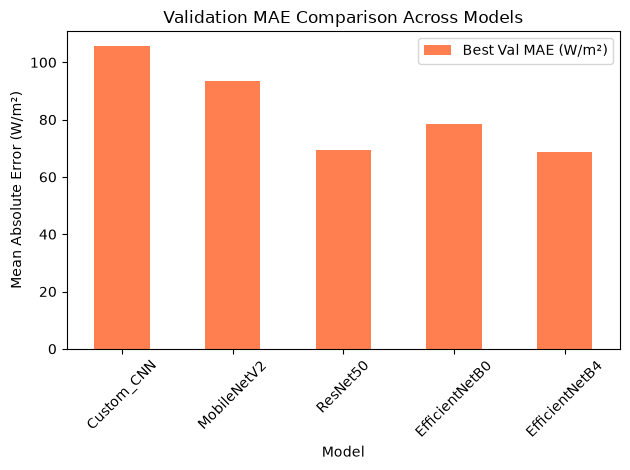

In [55]:
# ==========================================
# VISUALIZE FINAL MODEL COMPARISON
# ==========================================

results_df.plot(
    x="Model",
    y="Best Val MAE (W/m²)",
    kind="bar",
    color="coral",
    title="Validation MAE Comparison Across Models"
)

plt.ylabel("Mean Absolute Error (W/m²)")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()